In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
matched_data = pd.read_csv("matched_clinical_data.csv")

In [3]:
matched_data.head()

,Unnamed: 0,patient_id,Stage,Station,Age,Gender(Male=0),Hight,Weight,Real Dose,Pathology,...,soft tissue,spleen,bone marrow,Stomach,liver,lung,adrenal,Colon,soft tissue//cub,left parietal
0,Lymphoma_SH_00000000,ABAZARI SHIMA,2,6.0,28,1,1.70,63,285.785,Nodular Sclerosis,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
1,Lymphoma_SH_00000001,ABDOLLAHI AKBAR,4,15.0,50,0,1.83,89,408.091,Nodular Lymphocytic Predominant,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
2,Lymphoma_SH_00000002,ABEDI NOROUZ,1,1.0,55,0,1.75,77,354.605,DLBCL,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
3,Lymphoma_SH_00000003,ABZARIYAN MOHSEN,2,10.0,73,0,1.68,70,314.000,DLBCL,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
4,Lymphoma_SH_00000004,AGHAZADE ERFAN,2,8.0,16,0,1.77,75,359.674,DLBCL,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN


In [4]:
matched_data.columns

Index(['Unnamed: 0', 'patient_id', 'Stage', 'Station', 'Age', 'Gender(Male=0)',
       'Hight', 'Weight', 'Real Dose', 'Pathology', 'Binary Label',
       'تعداد روز', 'patho date ', 'BIOPSY R', '2Y-SURVIVAL (alive=0,dead=1)',
       '3Y-SURVIVAL', '4Y-SURVIVAL', '5Y-SURVIVAL', 'met(0:nadarad)', 'bone',
       'soft tissue', 'spleen', 'bone marrow', 'Stomach', 'liver', 'lung',
       'adrenal', 'Colon', 'soft tissue//cub', 'left parietal'],
      dtype='object')

In [6]:
def get_statistics_and_histogram_plot(data, column_name, hist_plot=True):
    print(f"======== Statistics for {column_name} ========")
    stats = data[column_name].describe()
    print(stats)
    print(f"Unique value counts for {column_name}:")
    print(data[column_name].value_counts())
    if hist_plot:
        plt.figure(figsize=(8, 5))
        sns.histplot(
            data[column_name],
            bins=30,
            kde=True,                     # adds a smooth density curve
            color='blue',              # choose a nice color
            edgecolor='black',            # outline bars
            linewidth=0.8
        )
        if column_name == "Binary Label":
            column_name = "(Non)Hodgkin lymphoma"
        elif column_name == "Hight":
            column_name = "Height"
        plt.title(f'Histogram of {column_name}', fontsize=14, fontweight='bold', pad=15)
        plt.xlabel(column_name, fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        plt.grid(axis='y', linestyle='--', alpha=0.6)  # subtle horizontal gridlines
        sns.despine()  # removes top and right spines for a cleaner look
        plt.tight_layout()
        plt.savefig(f'../results/data_analysis/{column_name}_histogram.png', dpi=100)
        plt.show()

        

In [ ]:
for column in ['Binary Label', 'Stage', 'Age', 'Gender(Male=0)', 'Hight', 'Weight']:
    get_statistics_and_histogram_plot(matched_data, column, hist_plot=True)
# get_statistics_and_histogram_plot(matched_data, 'Stage')

# new dataset

In [1]:
import pandas as pd



In [5]:
biopsy_info = pd.read_excel("../../new_dataset/biopsy_info.xlsx")
biopsy_info.head()

,patient_id,Stage,Age,"Gender(Male=0, Fmale:1)",Binary Label
0,ABAZARI SHIMA,2,28,1,HL
1,ABDOLLAHI AKBAR,4,50,0,HL
2,ABEDI NOROUZ,1,55,0,NHL
3,ABZARIYAN MOHSEN,2,73,0,NHL
4,ADL AMINI REZA,2,27,0,HL


In [11]:
biopsy_info['patient_id'].values

array(['ABAZARI SHIMA ', 'ABDOLLAHI AKBAR ', 'ABEDI NOROUZ ',
       'ABZARIYAN MOHSEN', 'ADL  AMINI  REZA ', 'AGHAZADE  ERFAN',
       'AHMADI AMIR HOSEIN ', 'AHMADI ZAMANI ILIYA ', 'ALAVI AMIR SAED',
       'ALBORZI ARMAN ', 'ALEM ZADEH SHABNAM ', 'ALI  AKBARI MAJD MAJID',
       'ALI HOSEYNI FAEZEH', 'ALI KARIM HEYDAR ', 'ALI NAGHIAN FATEMEH',
       'ALI SALEM SALIMEH', 'ALIJANI HAMID', 'ALIREZAIE ELAHEH ',
       'ALISHAHI  MOHAMADJAVAD', 'AMIRI KAMAND', 'ARDEBILI YAGHOUB',
       'ARDESTANI HOUSHANG ', 'AROONI KASHANI  AZRA ', 'ASADI MOHAMMAD ',
       'ASADI SIRCHI HESAMODIN', 'AZHDARI MORTEZA ', 'AZHDARI VAHIDEH ',
       'BADIEI  MARJAM ', 'BAHRAM POURI GH. HASAN', 'BASERI  HASAN',
       'BEHROOYAN JAFAR ', 'BEROOKHIM ROOHOLAH ', 'BEYGI  TANAZ ',
       'BIRJANDIFAR HAMIDREZA ', 'BONYADI SOMAYEH ', 'BOSHAGH FATEMEH ',
       'CHAVOSHI KOMEYL ', 'DASHTI REZVAN', 'DAVOD POUR MILAD ',
       'DEHGHAN NAYERI MARZIYEH BEYGOM ', 'DERAKHSHAN GHOLAMREZA ',
       'DIBAJ  SEYEDE ZAHRA

======== Statistics for Stage ========
count    241.000000
mean       2.742739
std        1.036922
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        4.000000
Name: Stage, dtype: float64
Unique value counts for Stage:
Stage
2    96
4    82
3    39
1    24
Name: count, dtype: int64


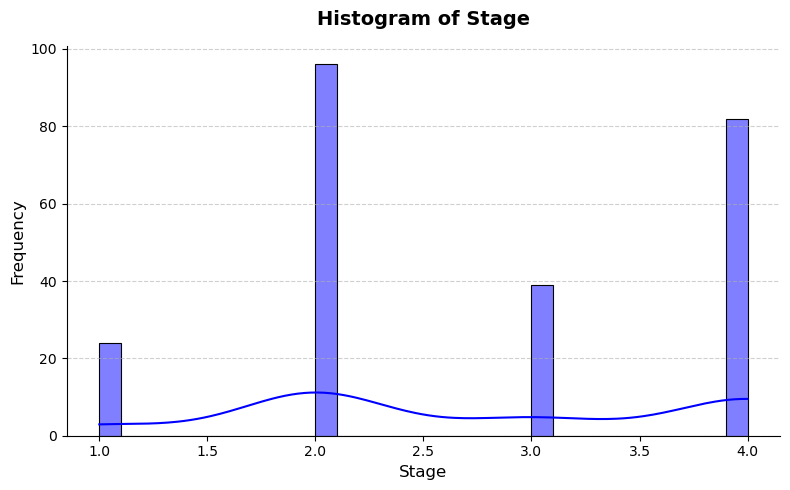

======== Statistics for Age ========
count    241.000000
mean      43.232365
std       20.285975
min        5.000000
25%       27.000000
50%       44.000000
75%       59.000000
max       94.000000
Name: Age, dtype: float64
Unique value counts for Age:
Age
27    9
31    9
61    8
33    7
52    7
     ..
94    1
42    1
91    1
78    1
68    1
Name: count, Length: 81, dtype: int64


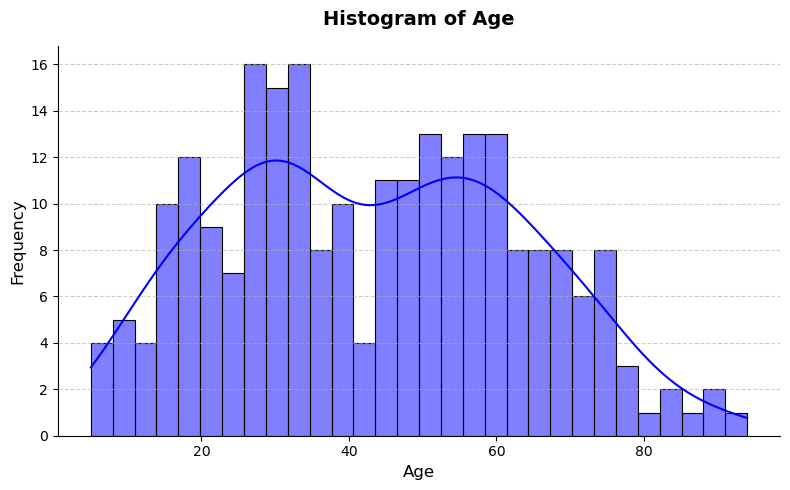

======== Statistics for Gender(Male=0, Fmale:1) ========
count    241.000000
mean       0.406639
std        0.492229
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: Gender(Male=0, Fmale:1), dtype: float64
Unique value counts for Gender(Male=0, Fmale:1):
Gender(Male=0, Fmale:1)
0    143
1     98
Name: count, dtype: int64


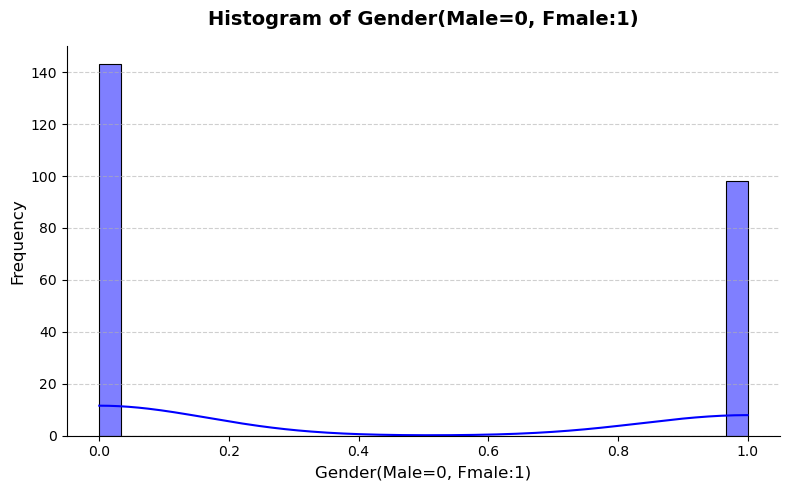

======== Statistics for Binary Label ========
count     241
unique      2
top        HL
freq      125
Name: Binary Label, dtype: object
Unique value counts for Binary Label:
Binary Label
HL     125
NHL    116
Name: count, dtype: int64


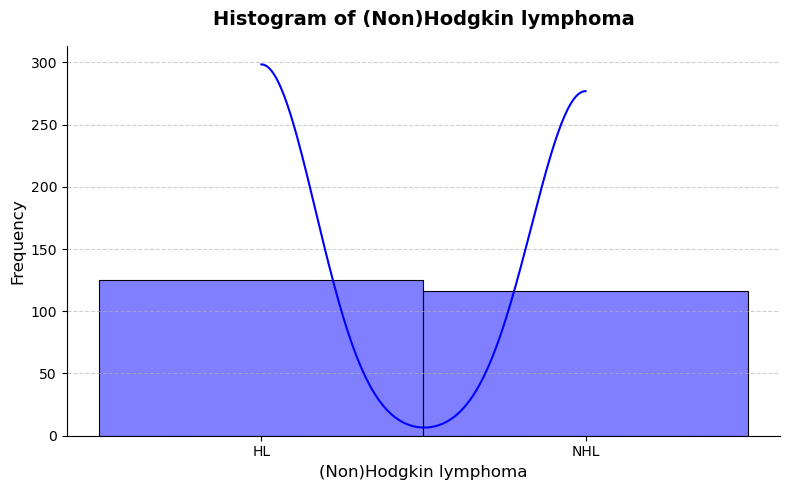

In [9]:
for column in ['Stage', 'Age', 'Gender(Male=0, Fmale:1)', 'Binary Label']:
    get_statistics_and_histogram_plot(biopsy_info, column, hist_plot=True)